In [4]:
import tensorflow as tf
import numpy as np
import os
import sys


def analyze_model_architecture(model_path):
    """
    Load a Keras model and print its architecture in a detailed format.

    Args:
        model_path: Path to the saved Keras model
    """
    # Check if file exists
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at {model_path}")
        return

    # Load the model
    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"Error loading model: {e}")
        return

    # Print basic model information
    print("\n" + "=" * 50)
    print(f"MODEL ARCHITECTURE ANALYSIS")
    print("=" * 50)

    # Count total parameters
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params

    print(f"\nTotal Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-trainable Parameters: {non_trainable_params:,}")

    # Print detailed layer information
    print("\nLayer by Layer Analysis:")
    print("-" * 80)
    print(f"{'#':<4} {'Layer Type':<20} {'Output Shape':<20} {'Parameters':<15} {'Details':<30}")
    print("-" * 80)

    for i, layer in enumerate(model.layers):
        # Get layer details
        layer_type = layer.__class__.__name__
        output_shape = str(layer.output.shape)  # Fixed - use layer.output.shape instead of layer.output_shape
        params = layer.count_params()

        # Get layer-specific details
        details = ""

        if "Conv" in layer_type:
            # Convolutional layer
            details = f"kernel_size: {layer.kernel_size}, filters: {layer.filters}"
            if hasattr(layer, 'strides'):
                details += f", strides: {layer.strides}"

        elif "Pool" in layer_type:
            # Pooling layer
            if hasattr(layer, 'pool_size'):
                details = f"kernel_size: {layer.pool_size}"
            if hasattr(layer, 'strides'):
                details += f", strides: {layer.strides}"

        elif "Dense" in layer_type:
            # Fully connected layer
            details = f"neurons: {layer.units}"

        elif "Dropout" in layer_type:
            # Dropout layer
            details = f"rate: {layer.rate}"

        elif "BatchNorm" in layer_type:
            # Batch normalization layer
            details = "batch normalization"

        elif "Activation" in layer_type:
            # Activation layer
            details = f"function: {layer.activation.__name__ if hasattr(layer.activation, '__name__') else str(layer.activation)}"

        elif "Flatten" in layer_type:
            # Flatten layer
            details = "flattens input"

        # Print the layer information
        print(f"{i:<4} {layer_type:<20} {output_shape:<20} {params:<15,} {details:<30}")

    print("-" * 80)

    # Summarize architecture in a format similar to the one requested
    print("\nSummarized Architecture:")
    print("=====================\n")

    dataset_name = "Unknown"  # This information is not stored in the model file

    print(f"Dataset: {dataset_name}")

    for i, layer in enumerate(model.layers):
        layer_type = layer.__class__.__name__

        if "Conv2D" in layer_type:
            kernel_h, kernel_w = layer.kernel_size
            filters = layer.filters
            print(f"Convolution kernel_size:{kernel_h} × {kernel_w}; output_filters:{filters}")

        elif "MaxPooling2D" in layer_type or "AveragePooling2D" in layer_type:
            pool_type = "MaxPooling" if "Max" in layer_type else "AveragePooling"
            pool_h, pool_w = layer.pool_size
            stride_h, stride_w = layer.strides
            print(f"{pool_type} kernel_size:{pool_h} × {pool_w}; strides:{stride_h} × {stride_w}")

        elif "Dense" in layer_type:
            # Only print the Dense layer if it's not the output layer
            # (assuming the last Dense layer is the output layer)
            if i < len(model.layers) - 1 or i == 0:
                neurons = layer.units
                print(f"Fully-Connected output_neurons:{neurons}")
            else:
                neurons = layer.units
                print(f"Fully-Connected output_neurons:{neurons} (Output Layer)")


In [6]:
model_path = "results/late_fusion_20250513_204715/depth/depth_model_final.keras"

analyze_model_architecture(model_path)


MODEL ARCHITECTURE ANALYSIS

Total Parameters: 314,620
Trainable Parameters: 314,532
Non-trainable Parameters: 88

Layer by Layer Analysis:
--------------------------------------------------------------------------------
#    Layer Type           Output Shape         Parameters      Details                       
--------------------------------------------------------------------------------
0    Conv2D               (None, 128, 64, 40)  1,960           kernel_size: (4, 4), filters: 40, strides: (1, 1)
1    BatchNormalization   (None, 128, 64, 40)  160             batch normalization           
2    Activation           (None, 128, 64, 40)  0               function: relu                
3    MaxPooling2D         (None, 63, 31, 40)   0               kernel_size: (3, 3), strides: (2, 2)
4    Flatten              (None, 78120)        0               flattens input                
5    Dropout              (None, 78120)        0               rate: 0.4                     
6    Dense    

# Early metrics

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [6]:
# Parse the experiment results text into a structured DataFrame

def parse_experiment_results(text):
    # Extract individual run results using regex
    pattern = r"Run (\d+) - Accuracy: ([\d.]+), Parameters: ([\d,]+), Time: ([\d.]+)s"
    matches = re.findall(pattern, text)

    # Create DataFrame
    data = []
    for match in matches:
        run_num = int(match[0])
        accuracy = float(match[1])
        parameters = int(match[2].replace(',', ''))  # Remove commas
        time = float(match[3])

        data.append({
            'Run': run_num,
            'Accuracy': accuracy,
            'Parameters': parameters,
            'Time': time
        })

    return pd.DataFrame(data)


# Extract data from provided text
df = parse_experiment_results("""
Run 1 - Accuracy: 0.9646, Parameters: 5,520,723, Time: 499.52s
Run 2 - Accuracy: 0.9750, Parameters: 8,327,156, Time: 1241.98s
Run 3 - Accuracy: 0.7458, Parameters: 46,077,351, Time: 864.19s
Run 4 - Accuracy: 0.9792, Parameters: 2,361,224, Time: 368.65s
Run 5 - Accuracy: 0.9750, Parameters: 213,683, Time: 230.01s
Run 6 - Accuracy: 0.9771, Parameters: 900,677, Time: 165.38s
Run 7 - Accuracy: 0.9646, Parameters: 3,776,387, Time: 324.08s
Run 8 - Accuracy: 0.9646, Parameters: 4,132,127, Time: 275.76s
Run 9 - Accuracy: 0.9646, Parameters: 1,543,239, Time: 299.92s
Run 10 - Accuracy: 0.9688, Parameters: 758,468, Time: 210.71s
Run 11 - Accuracy: 0.9688, Parameters: 3,397,358, Time: 261.17s
Run 12 - Accuracy: 0.9604, Parameters: 2,444,747, Time: 202.62s
Run 13 - Accuracy: 0.9750, Parameters: 759,296, Time: 235.58s
Run 14 - Accuracy: 0.9563, Parameters: 1,508,084, Time: 180.62s
Run 15 - Accuracy: 0.9708, Parameters: 2,314,184, Time: 288.57s
Run 16 - Accuracy: 0.9708, Parameters: 2,295,635, Time: 247.03s
Run 17 - Accuracy: 0.9688, Parameters: 3,516,040, Time: 340.57s
Run 18 - Accuracy: 0.9750, Parameters: 520,760, Time: 159.37s
Run 19 - Accuracy: 0.9646, Parameters: 2,324,739, Time: 257.81s
Run 20 - Accuracy: 0.9646, Parameters: 774,269, Time: 186.92s
""")

# Display the first few rows to verify data
df.head()
early_fusion_data = df

In [7]:
# Basic statistics of the dataset
df.describe()

,Run,Accuracy,Parameters,Time
count,20.00000,20.000000,2.000000e+01,20.000000
mean,10.50000,0.957720,4.673307e+06,342.023000
std,5.91608,0.050234,9.937975e+06,263.110821
min,1.00000,0.745800,2.136830e+05,159.370000
25%,5.75000,0.964600,8.690750e+05,208.687500
50%,10.50000,0.968800,2.319462e+06,259.490000
75%,15.25000,0.975000,3.581127e+06,328.202500
max,20.00000,0.979200,4.607735e+07,1241.980000


In [8]:
# Identify outliers in the Parameters column
Q1 = df['Parameters'].quantile(0.25)
Q3 = df['Parameters'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Print outlier information
print(f"Parameters column statistics:")
print(f"25th percentile (Q1): {Q1:,.0f}")
print(f"75th percentile (Q3): {Q3:,.0f}")
print(f"Interquartile Range (IQR): {IQR:,.0f}")
print(f"Lower bound for outliers: {lower_bound:,.0f}")
print(f"Upper bound for outliers: {upper_bound:,.0f}")

# Identify potential outliers
outliers = df[(df['Parameters'] < lower_bound) | (df['Parameters'] > upper_bound)]
print(f"\nPotential outliers ({len(outliers)} rows):")
print(outliers[['Run', 'Parameters']])

Parameters column statistics:
25th percentile (Q1): 869,075
75th percentile (Q3): 3,581,127
Interquartile Range (IQR): 2,712,052
Lower bound for outliers: -3,199,003
Upper bound for outliers: 7,649,204

Potential outliers (2 rows):
   Run  Parameters
1    2     8327156
2    3    46077351


In [9]:
import matplotlib.pyplot as plt
import numpy as np


def simple_bw_boxplot(data, title, ylim=(0.92, 1.0)):
    fig, ax = plt.subplots(figsize=(6, 4))

    # Basic boxplot in black and white
    boxplot = ax.boxplot(data,
                         patch_artist=False,  # No fill
                         widths=0.6,
                         showfliers=True,
                         notch=False)

    # Style adjustments (all black lines)
    for element in ['boxes', 'whiskers', 'caps', 'medians']:
        for line in boxplot[element]:
            line.set(color='black', linewidth=1.2)

    for flier in boxplot['fliers']:
        flier.set(marker='o', color='black', markersize=5, alpha=0.6)

    # Titles and labels
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(ylim)

    # Hide x-axis ticks since it's a single distribution
    ax.set_xticks([])

    # Grid for y-axis
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Sample size annotation
    ax.text(1, ylim[0] + 0.005, f'n = {len(data)}',
            ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    return fig, ax

# Example usage:
fig, ax = simple_bw_boxplot(df_clean['Accuracy_Standardized'],
                             'Early Fusion Accuracy', ylim=(0.92, 1.0))
plt.show()


NameError: name 'df_clean' is not defined

In [58]:
# We can also create a version that will allow comparing early-dataset vs late-dataset
# First, let's simulate some late-dataset results (you'll replace this with real data)
# Here I'm creating a mock dataframe for demonstration
# In practice, you would load this from another source

# For illustration purposes - replace with actual late-dataset accuracy values
late_accuracy = [0.9667, 0.9062, 0.9188, 0.9021, 0.9333, 0.9104, 0.9271, 0.9042, 0.9167, 0.9083]

# Convert to a DataFrame
late_df = pd.DataFrame({'Accuracy': late_accuracy})
late_df['Dataset'] = 'Late'
late_df['Accuracy_Standardized'] = late_df['Accuracy'].clip(lower=0.90)

# Add dataset label to early dataset
df_clean['Dataset'] = 'Early'

# Combine datasets
combined_df = pd.concat([df_clean[['Accuracy', 'Accuracy_Standardized', 'Dataset']],
                         late_df[['Accuracy', 'Accuracy_Standardized', 'Dataset']]])

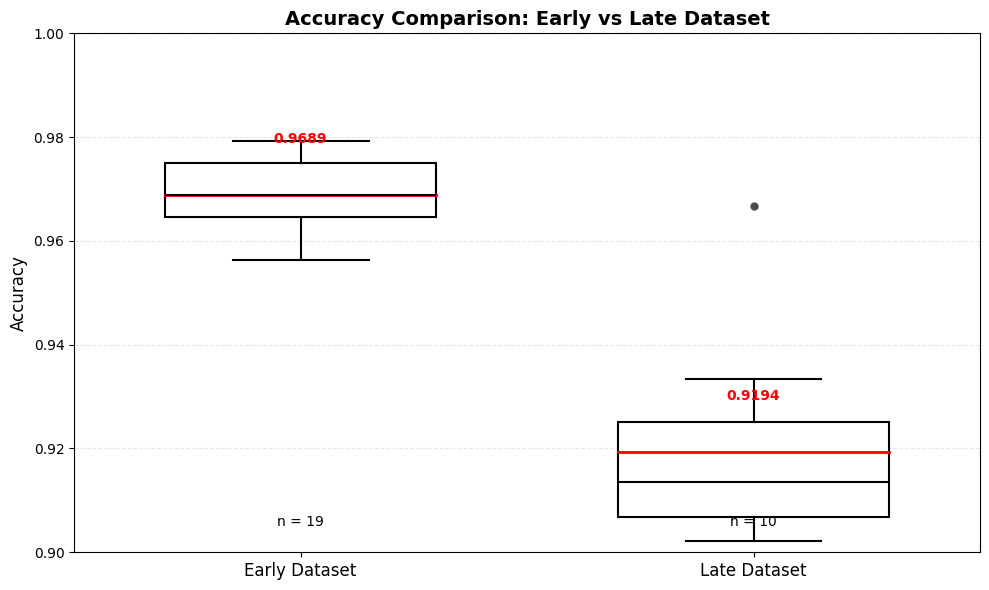

In [59]:
# Function to create comparative boxplots
def create_comparative_boxplots(data, x_col, y_col, title, ylim=(0.90, 1.0)):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create boxplots for each dataset
    boxplots = ax.boxplot([data[data[x_col] == 'Early'][y_col],
                           data[data[x_col] == 'Late'][y_col]],
                          positions=[1, 2],
                          patch_artist=True,
                          widths=0.6,
                          showfliers=True)

    # Customize boxplot appearance
    for box in boxplots['boxes']:
        box.set(facecolor='white', edgecolor='black', linewidth=1.5)

    for whisker in boxplots['whiskers']:
        whisker.set(color='black', linewidth=1.5)

    for cap in boxplots['caps']:
        cap.set(color='black', linewidth=1.5)

    for median in boxplots['medians']:
        median.set(color='black', linewidth=1.5)

    for flier in boxplots['fliers']:
        flier.set(marker='o', markerfacecolor='black', markeredgecolor='none',
                  markersize=6, alpha=0.7)

    # Add mean lines in red
    early_mean = data[data[x_col] == 'Early'][y_col].mean()
    late_mean = data[data[x_col] == 'Late'][y_col].mean()

    ax.plot([0.7, 1.3], [early_mean, early_mean], color='red', linewidth=2)
    ax.plot([1.7, 2.3], [late_mean, late_mean], color='red', linewidth=2)

    # Add mean text
    ax.text(1, early_mean + 0.01, f'{early_mean:.4f}',
            ha='center', color='red', fontweight='bold')
    ax.text(2, late_mean + 0.01, f'{late_mean:.4f}',
            ha='center', color='red', fontweight='bold')

    # Set labels and title
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Early Dataset', 'Late Dataset'], fontsize=12)
    ax.set_ylim(ylim)

    # Add grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Add sample size
    early_n = len(data[data[x_col] == 'Early'])
    late_n = len(data[data[x_col] == 'Late'])
    ax.text(1, ylim[0] + 0.005, f'n = {early_n}', ha='center')
    ax.text(2, ylim[0] + 0.005, f'n = {late_n}', ha='center')

    plt.tight_layout()
    return fig, ax


# Create comparative boxplots
fig, ax = create_comparative_boxplots(combined_df,
                                      'Dataset',
                                      'Accuracy_Standardized',
                                      'Accuracy Comparison: Early vs Late Dataset',
                                      ylim=(0.90, 1.0))

plt.show()

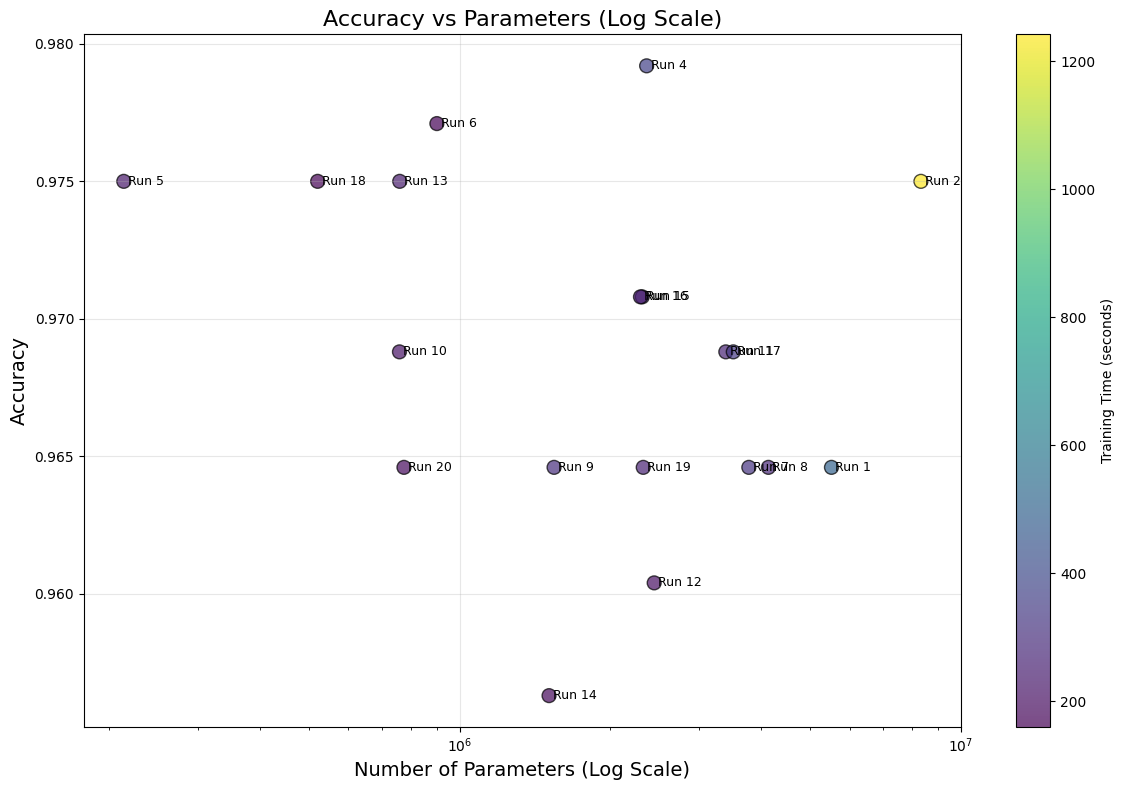

In [60]:
# Create a scatter plot to explore the relationship between Accuracy and Parameters
plt.figure(figsize=(12, 8))

# Use log scale for Parameters to better visualize the distribution
plt.scatter(df_clean['Parameters'], df_clean['Accuracy'],
            c=df_clean['Time'], cmap='viridis',
            s=100, alpha=0.7, edgecolors='black')

plt.xscale('log')
plt.title('Accuracy vs Parameters (Log Scale)', fontsize=16)
plt.xlabel('Number of Parameters (Log Scale)', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Training Time (seconds)')

# Add run numbers as labels
for i, row in df_clean.iterrows():
    plt.text(row['Parameters'], row['Accuracy'], f" Run {row['Run']}",
             fontsize=9, verticalalignment='center')

plt.tight_layout()
plt.show()

In [61]:
# Compute correlation coefficients
correlation_accuracy_params = df_clean['Accuracy'].corr(df_clean['Parameters'])
correlation_accuracy_time = df_clean['Accuracy'].corr(df_clean['Time'])
correlation_params_time = df_clean['Parameters'].corr(df_clean['Time'])

print(f"Correlation between Accuracy and Parameters: {correlation_accuracy_params:.4f}")
print(f"Correlation between Accuracy and Training Time: {correlation_accuracy_time:.4f}")
print(f"Correlation between Parameters and Training Time: {correlation_params_time:.4f}")

Correlation between Accuracy and Parameters: -0.0757
Correlation between Accuracy and Training Time: 0.2172
Correlation between Parameters and Training Time: 0.8534


/var/folders/33/sjppm8gj2j19_4x5v46742xw0000gn/T/ipykernel_30869/281362492.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model Size', y='Accuracy', data=df_clean, palette='Set3')


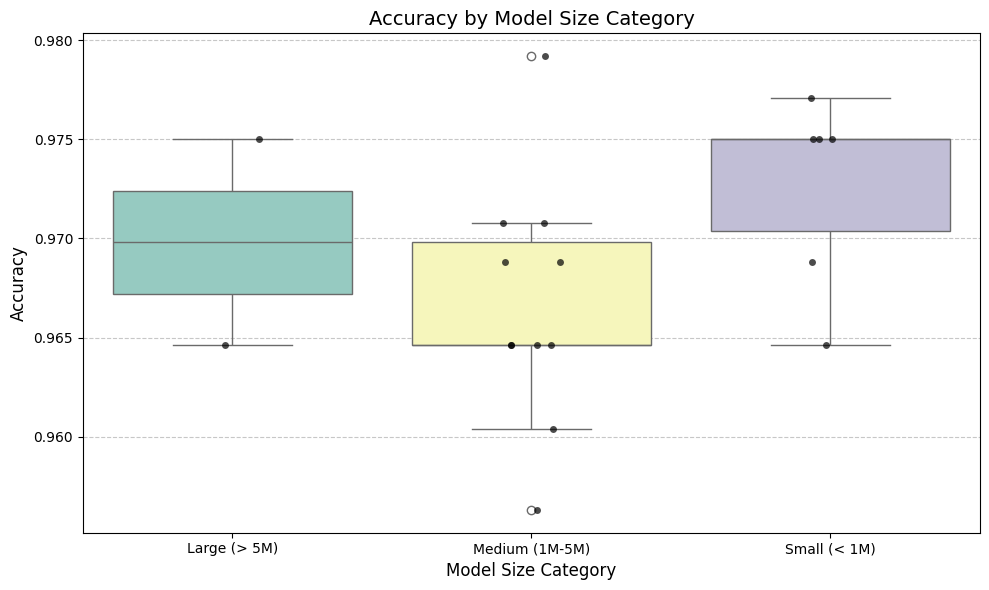

In [62]:
# Group models into parameter size categories
def categorize_model_size(params):
    if params < 1_000_000:  # Less than 1M parameters
        return 'Small (< 1M)'
    elif params < 5_000_000:  # Between 1M and 5M parameters
        return 'Medium (1M-5M)'
    else:  # More than 5M parameters
        return 'Large (> 5M)'


df_clean['Model Size'] = df_clean['Parameters'].apply(categorize_model_size)

# Compare accuracy across model size categories
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model Size', y='Accuracy', data=df_clean, palette='Set3')
sns.stripplot(x='Model Size', y='Accuracy', data=df_clean, color='black', alpha=0.7)

plt.title('Accuracy by Model Size Category', fontsize=14)
plt.xlabel('Model Size Category', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [63]:
# Summary statistics by model size category
size_summary = df_clean.groupby('Model Size').agg({
    'Accuracy': ['mean', 'std', 'min', 'max', 'count'],
    'Parameters': ['mean', 'min', 'max'],
    'Time': ['mean', 'min', 'max']
})

print("Summary Statistics by Model Size Category:")
print(size_summary)

Summary Statistics by Model Size Category:
                Accuracy                                    Parameters  \
                    mean       std     min     max count          mean   
Model Size                                                               
Large (> 5M)    0.969800  0.007354  0.9646  0.9750     2  6.923940e+06   
Medium (1M-5M)  0.966682  0.006035  0.9563  0.9792    11  2.692160e+06   
Small (< 1M)    0.972583  0.004816  0.9646  0.9771     6  6.545255e+05   

                                        Time                   
                    min      max        mean     min      max  
Model Size                                                     
Large (> 5M)    5520723  8327156  870.750000  499.52  1241.98  
Medium (1M-5M)  1508084  4132127  276.981818  180.62   368.65  
Small (< 1M)     213683   900677  197.995000  159.37   235.58  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
early_fusion_runs_data = [
    {'Run': 1, 'Accuracy': 0.9792, 'Parameters': 171560, 'Time': 192.32, 'type': 'Early Fusion'},
    {'Run': 2, 'Accuracy': 0.9792, 'Parameters': 164839, 'Time': 234.36, 'type': 'Early Fusion'},
    {'Run': 3, 'Accuracy': 0.9729, 'Parameters': 821672, 'Time': 173.19, 'type': 'Early Fusion'},
    {'Run': 4, 'Accuracy': 0.9729, 'Parameters': 2579865, 'Time': 269.82, 'type': 'Early Fusion'},
    {'Run': 5, 'Accuracy': 0.9750, 'Parameters': 213683, 'Time': 230.01, 'type': 'Early Fusion'},
    {'Run': 6, 'Accuracy': 0.9771, 'Parameters': 900677, 'Time': 165.38, 'type': 'Early Fusion'},
    {'Run': 7, 'Accuracy': 0.9646, 'Parameters': 3776387, 'Time': 324.08, 'type': 'Early Fusion'},
    {'Run': 8, 'Accuracy': 0.9646, 'Parameters': 4132127, 'Time': 275.76, 'type': 'Early Fusion'},
    {'Run': 9, 'Accuracy': 0.9646, 'Parameters': 1543239, 'Time': 299.92, 'type': 'Early Fusion'},
    {'Run': 10, 'Accuracy': 0.9688, 'Parameters': 758468, 'Time': 210.71, 'type': 'Early Fusion'},
    {'Run': 11, 'Accuracy': 0.9688, 'Parameters': 3397358, 'Time': 261.17, 'type': 'Early Fusion'},
    {'Run': 12, 'Accuracy': 0.9604, 'Parameters': 2444747, 'Time': 202.62, 'type': 'Early Fusion'},
    {'Run': 13, 'Accuracy': 0.9750, 'Parameters': 759296, 'Time': 235.58, 'type': 'Early Fusion'},
    {'Run': 14, 'Accuracy': 0.9563, 'Parameters': 1508084, 'Time': 180.62, 'type': 'Early Fusion'},
    {'Run': 15, 'Accuracy': 0.9708, 'Parameters': 2314184, 'Time': 288.57, 'type': 'Early Fusion'},
    {'Run': 16, 'Accuracy': 0.9708, 'Parameters': 2295635, 'Time': 247.03, 'type': 'Early Fusion'},
    {'Run': 17, 'Accuracy': 0.9688, 'Parameters': 3516040, 'Time': 340.57, 'type': 'Early Fusion'},
    {'Run': 18, 'Accuracy': 0.9750, 'Parameters': 520760, 'Time': 159.37, 'type': 'Early Fusion'},
    {'Run': 19, 'Accuracy': 0.9646, 'Parameters': 2324739, 'Time': 257.81, 'type': 'Early Fusion'},
    {'Run': 20, 'Accuracy': 0.9646, 'Parameters': 774269, 'Time': 186.92, 'type': 'Early Fusion'}
]
df_early_fusion = pd.DataFrame(early_fusion_runs_data)

Top 5 Most Efficient Early Fusion Models (High Accuracy with Fewer Parameters):
    Run  Accuracy  Parameters    Time  Efficiency
1     2    0.9792      164839  234.36    0.187692
0     1    0.9792      171560  192.32    0.187070
4     5    0.9750      213683  230.01    0.182935
17   18    0.9750      520760  159.37    0.170555
12   13    0.9750      759296  235.58    0.165805


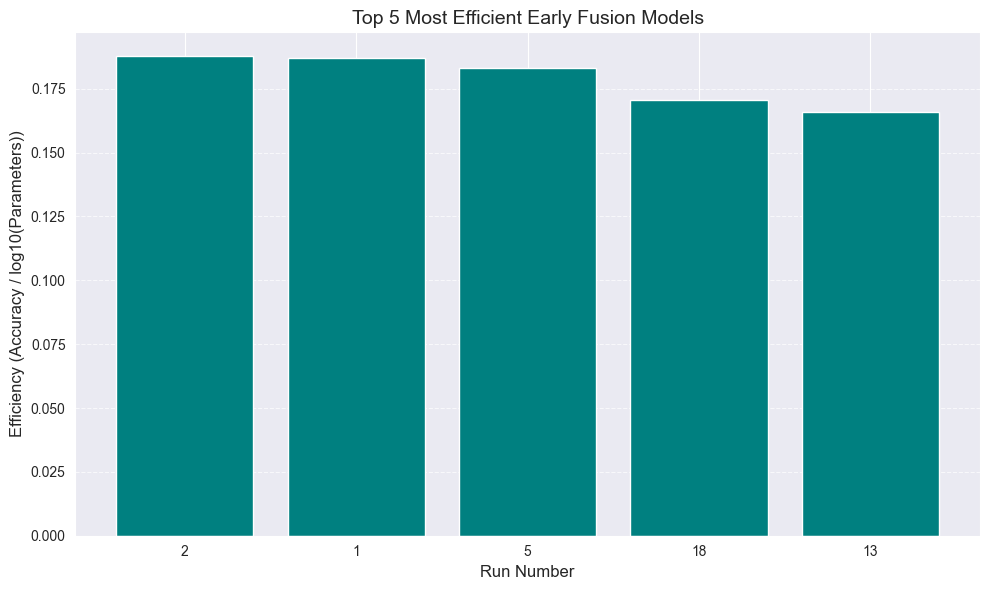

In [3]:

# Calculate efficiency
df_early_fusion['Efficiency'] = df_early_fusion['Accuracy'] / np.log10(df_early_fusion['Parameters'])

# Get top 5 most efficient models
top_efficient = df_early_fusion.sort_values(by='Efficiency', ascending=False).head(5)

# Display top 5
print("Top 5 Most Efficient Early Fusion Models (High Accuracy with Fewer Parameters):")
print(top_efficient[['Run', 'Accuracy', 'Parameters', 'Time', 'Efficiency']])

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(top_efficient['Run'].astype(str), top_efficient['Efficiency'], color='teal')
plt.title('Top 5 Most Efficient Early Fusion Models', fontsize=14)
plt.xlabel('Run Number', fontsize=12)
plt.ylabel('Efficiency (Accuracy / log10(Parameters))', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Late metrics

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

In [5]:
# Function to parse metrics from all_metrics_summary.txt files
def parse_metrics_file(file_path):
    with open(file_path, 'r') as f:
        content = f.read()

    # Extract experiment name from path
    experiment_name = os.path.basename(os.path.dirname(file_path))

    # Extract color model metrics
    color_accuracy = float(re.search(r"Color Model Metrics:.*?accuracy: ([\d\.]+)", content, re.DOTALL).group(1))
    color_precision = float(re.search(r"Color Model Metrics:.*?precision: ([\d\.]+)", content, re.DOTALL).group(1))
    color_recall = float(re.search(r"Color Model Metrics:.*?recall: ([\d\.]+)", content, re.DOTALL).group(1))
    color_f1 = float(re.search(r"Color Model Metrics:.*?f1_score: ([\d\.]+)", content, re.DOTALL).group(1))
    color_params = int(re.search(r"Color Model Metrics:.*?parameters: (\d+)", content, re.DOTALL).group(1))

    # Extract depth model metrics
    depth_accuracy = float(re.search(r"Depth Model Metrics:.*?accuracy: ([\d\.]+)", content, re.DOTALL).group(1))
    depth_precision = float(re.search(r"Depth Model Metrics:.*?precision: ([\d\.]+)", content, re.DOTALL).group(1))
    depth_recall = float(re.search(r"Depth Model Metrics:.*?recall: ([\d\.]+)", content, re.DOTALL).group(1))
    depth_f1 = float(re.search(r"Depth Model Metrics:.*?f1_score: ([\d\.]+)", content, re.DOTALL).group(1))
    depth_params = int(re.search(r"Depth Model Metrics:.*?parameters: (\d+)", content, re.DOTALL).group(1))

    # Extract fusion model metrics
    fusion_section = re.search(r"Fusion Model Metrics:(.*?)Total Workflow Time", content, re.DOTALL).group(1)
    fusion_accuracy = float(re.search(r"accuracy: ([\d\.]+)", fusion_section, re.DOTALL).group(1))
    fusion_precision = float(re.search(r"precision: ([\d\.]+)", fusion_section, re.DOTALL).group(1))
    fusion_recall = float(re.search(r"recall: ([\d\.]+)", fusion_section, re.DOTALL).group(1))
    fusion_f1 = float(re.search(r"f1_score: ([\d\.]+)", fusion_section, re.DOTALL).group(1))

    # Determine fusion type (weighted or unweighted)
    fusion_type = "weighted" if "20250512_185641" in experiment_name or any(date in experiment_name for date in
                                                                            ["20250512_19",
                                                                             "20250513_"]) else "unweighted"

    return {
        "experiment": experiment_name,
        "fusion_type": fusion_type,
        "color_accuracy": color_accuracy,
        "color_precision": color_precision,
        "color_recall": color_recall,
        "color_f1": color_f1,
        "color_params": color_params,
        "depth_accuracy": depth_accuracy,
        "depth_precision": depth_precision,
        "depth_recall": depth_recall,
        "depth_f1": depth_f1,
        "depth_params": depth_params,
        "fusion_accuracy": fusion_accuracy,
        "fusion_precision": fusion_precision,
        "fusion_recall": fusion_recall,
        "fusion_f1": fusion_f1
    }

In [17]:
# Function to parse metrics from all_metrics_summary.txt files
def parse_metrics_file(file_path):
    with open(file_path, 'r') as f:
        content = f.read()

    # Extract experiment name from path
    experiment_name = os.path.basename(os.path.dirname(file_path))

    # Extract color model metrics
    color_accuracy = float(re.search(r"Color Model Metrics:.*?accuracy: ([\d\.]+)", content, re.DOTALL).group(1))
    color_precision = float(re.search(r"Color Model Metrics:.*?precision: ([\d\.]+)", content, re.DOTALL).group(1))
    color_recall = float(re.search(r"Color Model Metrics:.*?recall: ([\d\.]+)", content, re.DOTALL).group(1))
    color_f1 = float(re.search(r"Color Model Metrics:.*?f1_score: ([\d\.]+)", content, re.DOTALL).group(1))
    color_params = int(re.search(r"Color Model Metrics:.*?parameters: (\d+)", content, re.DOTALL).group(1))

    # Extract depth model metrics
    depth_accuracy = float(re.search(r"Depth Model Metrics:.*?accuracy: ([\d\.]+)", content, re.DOTALL).group(1))
    depth_precision = float(re.search(r"Depth Model Metrics:.*?precision: ([\d\.]+)", content, re.DOTALL).group(1))
    depth_recall = float(re.search(r"Depth Model Metrics:.*?recall: ([\d\.]+)", content, re.DOTALL).group(1))
    depth_f1 = float(re.search(r"Depth Model Metrics:.*?f1_score: ([\d\.]+)", content, re.DOTALL).group(1))
    depth_params = int(re.search(r"Depth Model Metrics:.*?parameters: (\d+)", content, re.DOTALL).group(1))

    # Extract fusion model metrics
    fusion_section = re.search(r"Fusion Model Metrics:(.*?)Total Workflow Time", content, re.DOTALL).group(1)
    fusion_accuracy = float(re.search(r"accuracy: ([\d\.]+)", fusion_section).group(1))
    fusion_precision = float(re.search(r"precision: ([\d\.]+)", fusion_section).group(1))
    fusion_recall = float(re.search(r"recall: ([\d\.]+)", fusion_section).group(1))
    fusion_f1 = float(re.search(r"f1_score: ([\d\.]+)", fusion_section).group(1))

    # Determine fusion type (weighted or unweighted)
    averaging_type = "weighted" if "20250512_185641" in experiment_name or any(date in experiment_name for date in
                                                                               ["20250512_19",
                                                                                "20250513_"]) else "unweighted"

    return {
        "experiment": experiment_name,
        "fusion_type": averaging_type,
        "color_accuracy": color_accuracy,
        "color_precision": color_precision,
        "color_recall": color_recall,
        "color_f1": color_f1,
        "color_params": color_params,
        "depth_accuracy": depth_accuracy,
        "depth_precision": depth_precision,
        "depth_recall": depth_recall,
        "depth_f1": depth_f1,
        "depth_params": depth_params,
        "fusion_accuracy": fusion_accuracy,
        "fusion_precision": fusion_precision,
        "fusion_recall": fusion_recall,
        "fusion_f1": fusion_f1
    }


# Define the directories containing the metrics files
unweighted_dirs = [
   "results/late_fusion_20250511_152953",
   "results/late_fusion_20250511_165953",
   "results/late_fusion_20250512_143931",
   "results/late_fusion_20250512_150309",
   "results/late_fusion_20250512_164107",
   "results/late_fusion_20250512_175256",
   "results/late_fusion_20250512_175852",
   "results/late_fusion_20250512_183756",
    "results/late_fusion_20250514_112025",
    "results/late_fusion_20250514_113312"
]

weighted_dirs = [
    "results/late_fusion_20250512_185641_start_of_weighted_averaging",
    "results/late_fusion_20250512_190658",
    "results/late_fusion_20250512_194222",
    "results/late_fusion_20250512_195308",
    "results/late_fusion_20250512_200108",
    "results/late_fusion_20250513_181720",
    "results/late_fusion_20250513_182755",
    "results/late_fusion_20250513_183244",
    "results/late_fusion_20250513_183737",
    "results/late_fusion_20250513_202144",
    "results/late_fusion_20250513_202723",
    "results/late_fusion_20250513_203333",
    "results/late_fusion_20250513_204003",
    "results/late_fusion_20250513_204715",
    "results/late_fusion_20250513_205310",
    "results/late_fusion_20250513_210122",
    "results/late_fusion_20250513_210843",
    "results/late_fusion_20250513_211646",
    "results/late_fusion_20250513_212457",
    "results/late_fusion_20250513_213242"
]

# Process all the experiment directories
all_dirs = unweighted_dirs + weighted_dirs
all_metrics = []

for directory in all_dirs:
    file_path = os.path.join(directory, "all_metrics_summary.txt")
    try:
        metrics = parse_metrics_file(file_path)
        all_metrics.append(metrics)
        print(f"Processed: {directory}")
    except Exception as e:
        print(f"Error processing {directory}: {e}")

# Convert to DataFrame
df_metrics = pd.DataFrame(all_metrics)

# Display the first few rows
df_metrics.head()


Processed: results/late_fusion_20250511_152953
Processed: results/late_fusion_20250511_165953
Processed: results/late_fusion_20250512_143931
Processed: results/late_fusion_20250512_150309
Processed: results/late_fusion_20250512_164107
Processed: results/late_fusion_20250512_175256
Processed: results/late_fusion_20250512_175852
Processed: results/late_fusion_20250512_183756
Processed: results/late_fusion_20250514_112025
Processed: results/late_fusion_20250514_113312
Processed: results/late_fusion_20250512_185641_start_of_weighted_averaging
Processed: results/late_fusion_20250512_190658
Processed: results/late_fusion_20250512_194222
Processed: results/late_fusion_20250512_195308
Processed: results/late_fusion_20250512_200108
Processed: results/late_fusion_20250513_181720
Processed: results/late_fusion_20250513_182755
Processed: results/late_fusion_20250513_183244
Processed: results/late_fusion_20250513_183737
Processed: results/late_fusion_20250513_202144
Processed: results/late_fusion_2

,experiment,fusion_type,color_accuracy,color_precision,color_recall,color_f1,color_params,depth_accuracy,depth_precision,depth_recall,depth_f1,depth_params,fusion_accuracy,fusion_precision,fusion_recall,fusion_f1
0,late_fusion_20250511_152953,unweighted,0.720833,0.814464,0.729594,0.677820,6354385,0.556250,0.814781,0.560511,0.544035,566148,0.679167,0.702255,0.684362,0.675681
1,late_fusion_20250511_165953,unweighted,0.975000,0.974716,0.975857,0.975125,635214,0.247917,0.280453,0.268595,0.179547,2291317,0.952083,0.953654,0.954262,0.952010
2,late_fusion_20250512_143931,unweighted,0.970833,0.970360,0.971889,0.970926,1000998,0.454167,0.796016,0.479591,0.377083,993477,0.945833,0.948384,0.947093,0.946462
3,late_fusion_20250512_150309,unweighted,0.952083,0.955010,0.954660,0.952205,1581202,0.933333,0.944211,0.930098,0.933720,1269676,0.662500,0.689253,0.665339,0.669630
4,late_fusion_20250512_164107,unweighted,0.962500,0.962313,0.963927,0.962430,471792,0.716667,0.856755,0.720676,0.726684,6637251,0.916667,0.924539,0.918939,0.917538


In [18]:
print(len(weighted_dirs))
print(len(unweighted_dirs))

20
10


In [19]:
# Basic statistics of the metrics
print("=== COLOR STREAM METRICS ===")
print(df_metrics[['color_accuracy', 'color_precision', 'color_recall', 'color_f1']].describe())

print("\n=== DEPTH STREAM METRICS ===")
print(df_metrics[['depth_accuracy', 'depth_precision', 'depth_recall', 'depth_f1']].describe())

print("\n=== FUSION METRICS ===")
print(df_metrics[['fusion_accuracy', 'fusion_precision', 'fusion_recall', 'fusion_f1']].describe())

# Compare unweighted vs weighted fusion
print("\n=== UNWEIGHTED VS WEIGHTED FUSION COMPARISON ===")
print(df_metrics.groupby('fusion_type')[['fusion_accuracy', 'fusion_precision',
                                         'fusion_recall', 'fusion_f1']].describe().round(4))

=== COLOR STREAM METRICS ===
       color_accuracy  color_precision  color_recall   color_f1
count       30.000000        30.000000     30.000000  30.000000
mean         0.958750         0.961885      0.960230   0.957271
std          0.045448         0.028552      0.044021   0.053222
min          0.720833         0.814464      0.729594   0.677820
25%          0.962500         0.962328      0.964094   0.962446
50%          0.966667         0.966661      0.968242   0.966584
75%          0.972917         0.972572      0.973409   0.972854
max          0.977083         0.977033      0.977464   0.977131

=== DEPTH STREAM METRICS ===
       depth_accuracy  depth_precision  depth_recall   depth_f1
count       30.000000        30.000000     30.000000  30.000000
mean         0.622361         0.752466      0.635454   0.591479
std          0.243039         0.228343      0.235247   0.279194
min          0.231250         0.174059      0.255164   0.121169
25%          0.390104         0.798209      0

In [11]:
# Function to create black and white boxplots with red mean line
def create_bw_boxplot(data, x_col, y_col, title, xlabel, ylabel, ylim=(0.40, 0.95)):
    fig, ax = plt.subplots(figsize=(12, 7))

    # Calculate positions for boxes
    x_positions = np.arange(len(data[x_col].unique()))

    # Create boxplots for each category
    boxplots = {}
    for i, category in enumerate(data[x_col].unique()):
        subset = data[data[x_col] == category][y_col]

        # Draw the boxplot
        box = ax.boxplot(subset, positions=[x_positions[i]], patch_artist=True,
                         widths=0.6, showfliers=True)

        # Store boxplot elements for later styling
        boxplots[category] = box

        # Add the mean line in red
        mean_val = subset.mean()
        ax.plot([x_positions[i] - 0.3, x_positions[i] + 0.3], [mean_val, mean_val],
                color='red', linewidth=2, solid_capstyle='round')

        # Add mean value as text
        ax.text(x_positions[i], mean_val + 0.02, f'{mean_val:.4f}',
                ha='center', va='bottom', color='red', fontweight='bold')

        # Add sample size
        ax.text(x_positions[i], ylim[0] + 0.02, f'n={len(subset)}',
                ha='center', va='bottom', fontsize=10)

    # Style all boxplots
    for cat_name, box in boxplots.items():
        for element in ['boxes', 'whiskers', 'caps', 'medians']:
            for item in box[element]:
                plt.setp(item, color='black')

        # Fill boxes with white
        for patch in box['boxes']:
            patch.set(facecolor='white', edgecolor='black', linewidth=1.5)

        # Style fliers
        for flier in box['fliers']:
            flier.set(marker='o', markerfacecolor='black', markeredgecolor='none',
                      markersize=6, alpha=0.7)

    # Set labels and title
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(data[x_col].unique())
    ax.set_ylim(ylim)

    # Add grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    return fig, ax

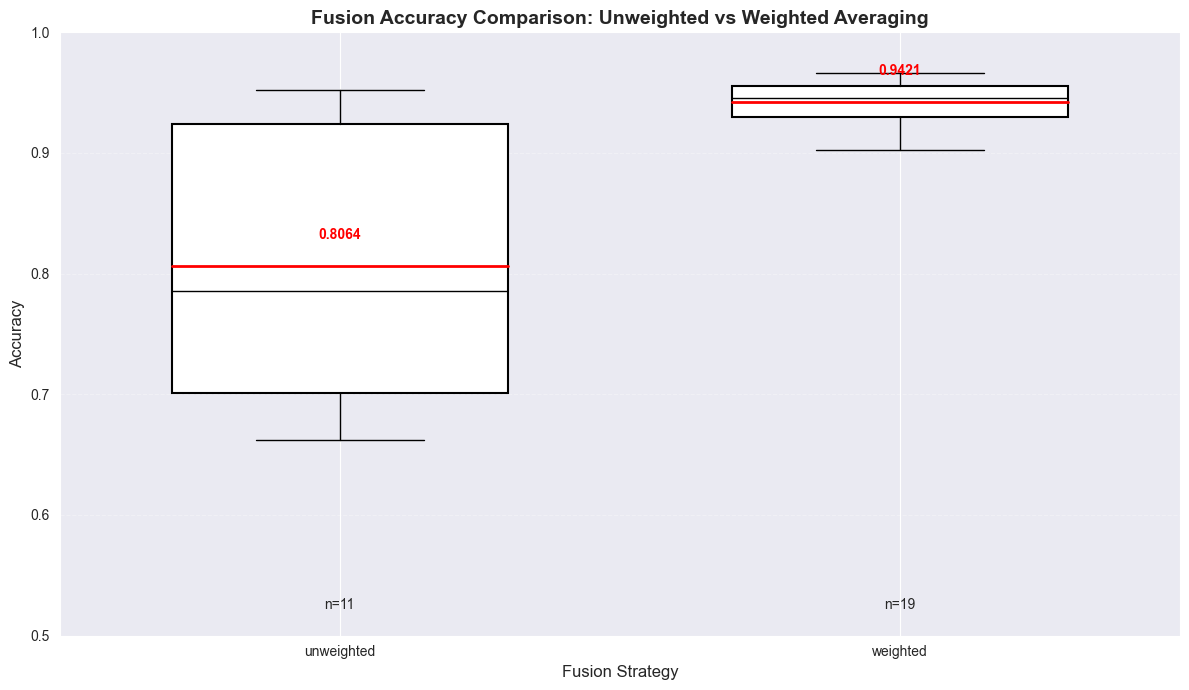

In [12]:
# Create a accuracy comparison boxplot for fusion types
fig, ax = create_bw_boxplot(
    data=df_metrics,
    x_col='fusion_type',
    y_col='fusion_accuracy',
    title='Fusion Accuracy Comparison: Unweighted vs Weighted Averaging',
    xlabel='Fusion Strategy',
    ylabel='Accuracy',
    ylim=(0.50, 1)
)
plt.show()

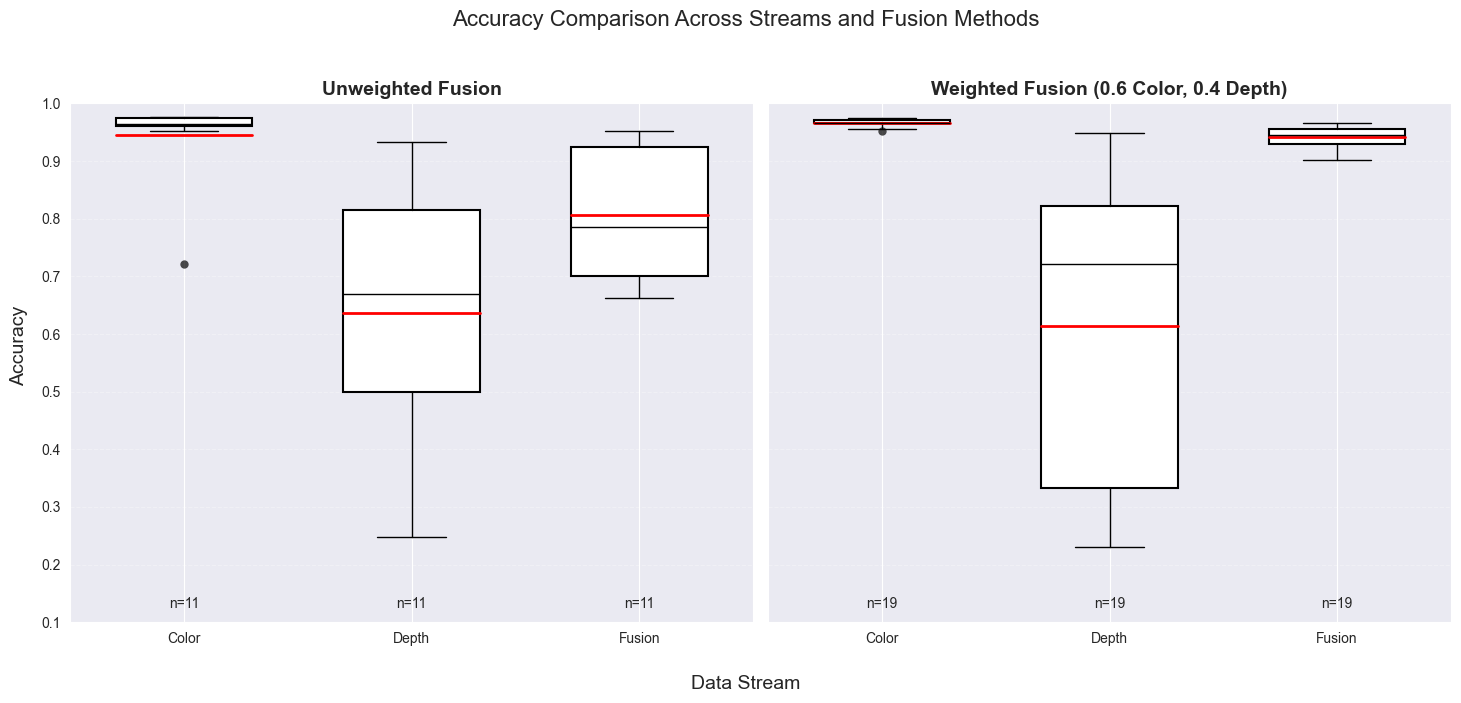

In [13]:
# Create a accuracy comparison boxplot for all streams
# First reshape data for better plotting
df_melted = pd.melt(
    df_metrics,
    id_vars=['experiment', 'fusion_type'],
    value_vars=['color_accuracy', 'depth_accuracy', 'fusion_accuracy'],
    var_name='stream',
    value_name='accuracy'
)

# Clean up stream names for display
df_melted['stream'] = df_melted['stream'].str.replace('_accuracy', '')

# Create separate dataframes for weighted and unweighted
df_unweighted = df_melted[df_melted['fusion_type'] == 'unweighted']
df_weighted = df_melted[df_melted['fusion_type'] == 'weighted']

# Create boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)


# Function to create boxplot on a specific axis
def create_stream_boxplot(data, ax, title, ylim=(0.40, 0.95)):
    # Calculate positions for boxes
    x_positions = np.arange(len(data['stream'].unique()))

    # Create boxplots for each stream
    boxplots = {}
    for i, category in enumerate(sorted(data['stream'].unique())):  # Sort to ensure consistent ordering
        subset = data[data['stream'] == category]['accuracy']

        # Draw the boxplot
        box = ax.boxplot(subset, positions=[x_positions[i]], patch_artist=True,
                         widths=0.6, showfliers=True)

        # Store boxplot elements for later styling
        boxplots[category] = box

        # Add the mean line in red
        mean_val = subset.mean()
        ax.plot([x_positions[i] - 0.3, x_positions[i] + 0.3], [mean_val, mean_val],
                color='red', linewidth=2, solid_capstyle='round')

        # # Add mean value as text
        # ax.text(x_positions[i], mean_val + 0.02, f'{mean_val:.4f}',
        #         ha='center', va='bottom', color='red', fontweight='bold')

        # Add sample size
        ax.text(x_positions[i], ylim[0] + 0.02, f'n={len(subset)}',
                ha='center', va='bottom', fontsize=10)

    # Style all boxplots
    for cat_name, box in boxplots.items():
        for element in ['boxes', 'whiskers', 'caps', 'medians']:
            for item in box[element]:
                plt.setp(item, color='black')

        # Fill boxes with white
        for patch in box['boxes']:
            patch.set(facecolor='white', edgecolor='black', linewidth=1.5)

        # Style fliers
        for flier in box['fliers']:
            flier.set(marker='o', markerfacecolor='black', markeredgecolor='none',
                      markersize=6, alpha=0.7)

    # Set labels and title
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels([s.capitalize() for s in sorted(data['stream'].unique())])
    ax.set_ylim(ylim)

    # Add grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)


# Create boxplot for unweighted fusion
create_stream_boxplot(
    data=df_unweighted,
    ax=ax1,
    title='Unweighted Fusion',
    ylim=(0.10, 1)
)

# Create boxplot for weighted fusion
create_stream_boxplot(
    data=df_weighted,
    ax=ax2,
    title='Weighted Fusion (0.6 Color, 0.4 Depth)',
    ylim=(0.10, 1)
)

# Set common labels
fig.suptitle('Accuracy Comparison Across Streams and Fusion Methods', fontsize=16)
fig.text(0.5, 0.01, 'Data Stream', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Accuracy', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])  # Adjust for the common labels
plt.show()

In [14]:
# Create a summary table for both fusion strategies
summary_table = df_metrics.groupby('fusion_type')[
    ['color_accuracy', 'depth_accuracy', 'fusion_accuracy']
].agg(['mean', 'std', 'min', 'max'])

print("=== SUMMARY STATISTICS BY FUSION STRATEGY ===")
print(summary_table.round(4))

# Calculate improvement of fusion over individual streams
# First for unweighted fusion
unweighted_df = df_metrics[df_metrics['fusion_type'] == 'unweighted']
weighted_df = df_metrics[df_metrics['fusion_type'] == 'weighted']

# For unweighted
color_improve_unweighted = ((unweighted_df['fusion_accuracy'] - unweighted_df['color_accuracy']) /
                            unweighted_df['color_accuracy']) * 100
depth_improve_unweighted = ((unweighted_df['fusion_accuracy'] - unweighted_df['depth_accuracy']) /
                            unweighted_df['depth_accuracy']) * 100

# For weighted
color_improve_weighted = ((weighted_df['fusion_accuracy'] - weighted_df['color_accuracy']) /
                          weighted_df['color_accuracy']) * 100
depth_improve_weighted = ((weighted_df['fusion_accuracy'] - weighted_df['depth_accuracy']) /
                          weighted_df['depth_accuracy']) * 100

print("\n=== AVERAGE IMPROVEMENT FROM FUSION (PERCENTAGE) ===")
print(f"Unweighted fusion vs Color: {color_improve_unweighted.mean():.2f}% improvement")
print(f"Unweighted fusion vs Depth: {depth_improve_unweighted.mean():.2f}% improvement")
print(f"Weighted fusion vs Color: {color_improve_weighted.mean():.2f}% improvement")
print(f"Weighted fusion vs Depth: {depth_improve_weighted.mean():.2f}% improvement")
print(
    f"\nWeighted vs Unweighted fusion: {((weighted_df['fusion_accuracy'].mean() / unweighted_df['fusion_accuracy'].mean()) - 1) * 100:.2f}% improvement")

=== SUMMARY STATISTICS BY FUSION STRATEGY ===
            color_accuracy                         depth_accuracy          \
                      mean     std     min     max           mean     std   
fusion_type                                                                 
unweighted          0.9449  0.0747  0.7208  0.9771         0.6371  0.2235   
weighted            0.9668  0.0062  0.9521  0.9750         0.6138  0.2593   

                            fusion_accuracy                          
                min     max            mean     std     min     max  
fusion_type                                                          
unweighted   0.2479  0.9333          0.8064  0.1168  0.6625  0.9521  
weighted     0.2312  0.9479          0.9421  0.0189  0.9021  0.9667  

=== AVERAGE IMPROVEMENT FROM FUSION (PERCENTAGE) ===
Unweighted fusion vs Color: -14.47% improvement
Unweighted fusion vs Depth: 50.68% improvement
Weighted fusion vs Color: -2.55% improvement
Weighted fusion vs Depth

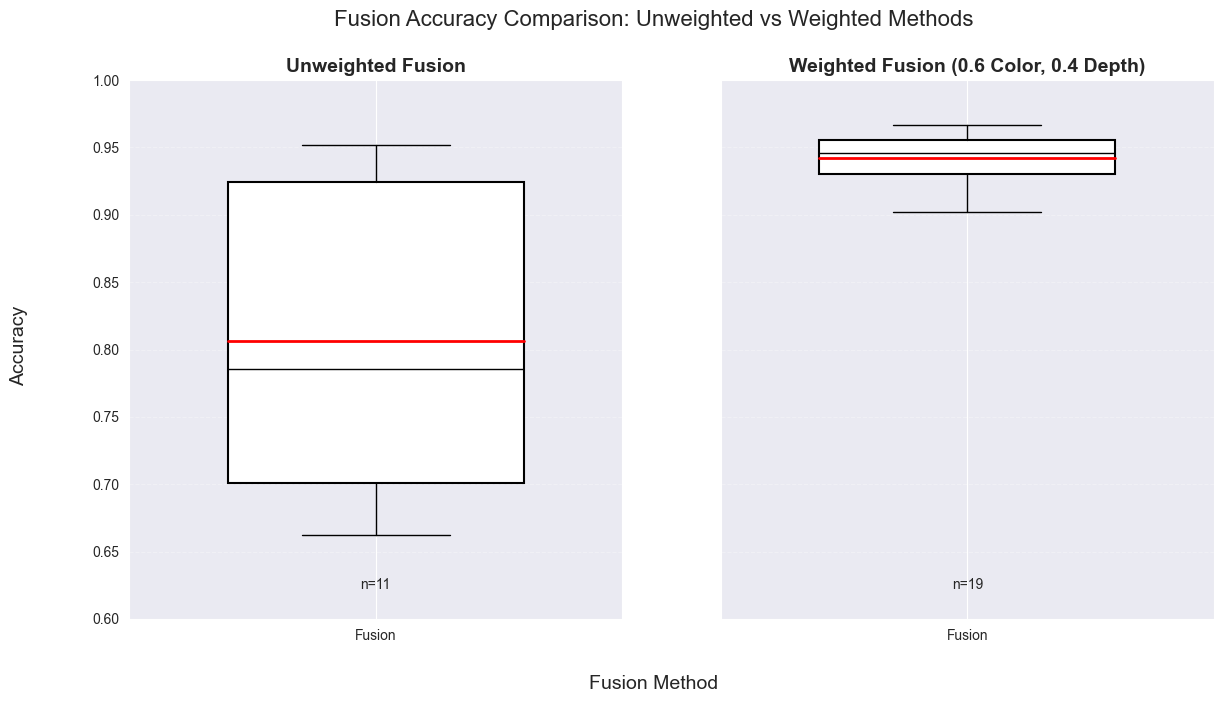

Unweighted Fusion Statistics:
  Mean: 0.8064
  Std: 0.1168
  Min: 0.6625
  Max: 0.9521
  Count: 11

Weighted Fusion Statistics:
  Mean: 0.9421
  Std: 0.0189
  Min: 0.9021
  Max: 0.9667
  Count: 19

Improvement with weighted fusion: 16.82%


In [15]:
# Create a comparison boxplot for fusion accuracy only
# First filter data to only include fusion accuracy
fusion_df = pd.melt(
    df_metrics,
    id_vars=['experiment', 'fusion_type'],
    value_vars=['fusion_accuracy'],
    var_name='stream',
    value_name='accuracy'
)

# Clean up stream names for display
fusion_df['stream'] = fusion_df['stream'].str.replace('_accuracy', '')

# Create separate dataframes for weighted and unweighted
df_unweighted_fusion = fusion_df[fusion_df['fusion_type'] == 'unweighted']
df_weighted_fusion = fusion_df[fusion_df['fusion_type'] == 'weighted']

# Create boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)


# Function to create boxplot on a specific axis
def create_fusion_boxplot(data, ax, title, ylim=(0.40, 0.95)):
    # Calculate position for box (only one stream now - fusion)
    x_position = 0

    # Get the subset of data
    subset = data['accuracy']

    # Draw the boxplot
    box = ax.boxplot(subset, positions=[x_position], patch_artist=True,
                     widths=0.6, showfliers=True)

    # Add the mean line in red
    mean_val = subset.mean()
    ax.plot([x_position - 0.3, x_position + 0.3], [mean_val, mean_val],
            color='red', linewidth=2, solid_capstyle='round')

    # Add mean value as text
    # ax.text(x_position, mean_val + 0.02, f'{mean_val:.4f}',
    #         ha='center', va='bottom', color='red', fontweight='bold')

    # Add sample size
    ax.text(x_position, ylim[0] + 0.02, f'n={len(subset)}',
            ha='center', va='bottom', fontsize=10)

    # Style the boxplot
    for element in ['boxes', 'whiskers', 'caps', 'medians']:
        for item in box[element]:
            plt.setp(item, color='black')

    # Fill boxes with white
    for patch in box['boxes']:
        patch.set(facecolor='white', edgecolor='black', linewidth=1.5)

    # Style fliers
    for flier in box['fliers']:
        flier.set(marker='o', markerfacecolor='black', markeredgecolor='none',
                  markersize=6, alpha=0.7)

    # Set labels and title
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks([x_position])
    ax.set_xticklabels(['Fusion'])
    ax.set_ylim(ylim)

    # Add grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)


# Create boxplot for unweighted fusion
create_fusion_boxplot(
    data=df_unweighted_fusion,
    ax=ax1,
    title='Unweighted Fusion',
    ylim=(0.60, 1.0)  # Adjusted for better visualization
)

# Create boxplot for weighted fusion
create_fusion_boxplot(
    data=df_weighted_fusion,
    ax=ax2,
    title='Weighted Fusion (0.6 Color, 0.4 Depth)',
    ylim=(0.60, 1.0)  # Adjusted for better visualization
)

# Set common labels
fig.suptitle('Fusion Accuracy Comparison: Unweighted vs Weighted Methods', fontsize=16)
fig.text(0.5, 0.01, 'Fusion Method', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Accuracy', va='center', rotation='vertical', fontsize=14)

# Add stats comparison
unweighted_mean = df_unweighted_fusion['accuracy'].mean()
weighted_mean = df_weighted_fusion['accuracy'].mean()
improvement = ((weighted_mean - unweighted_mean) / unweighted_mean) * 100

# stats_text = (
#     f"Statistical Comparison:\n"
#     f"Unweighted Mean: {unweighted_mean:.4f}\n"
#     f"Weighted Mean: {weighted_mean:.4f}\n"
#     f"Improvement: {improvement:.2f}%"
# )

# Add text at the bottom of the plot
# plt.figtext(0.5, 0.9, stats_text, ha='center', va='top',
#             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

# plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.88])  # Adjust for the common labels and stats text
plt.show()

# Print statistical details
print(f"Unweighted Fusion Statistics:")
print(f"  Mean: {unweighted_mean:.4f}")
print(f"  Std: {df_unweighted_fusion['accuracy'].std():.4f}")
print(f"  Min: {df_unweighted_fusion['accuracy'].min():.4f}")
print(f"  Max: {df_unweighted_fusion['accuracy'].max():.4f}")
print(f"  Count: {len(df_unweighted_fusion)}")
print()
print(f"Weighted Fusion Statistics:")
print(f"  Mean: {weighted_mean:.4f}")
print(f"  Std: {df_weighted_fusion['accuracy'].std():.4f}")
print(f"  Min: {df_weighted_fusion['accuracy'].min():.4f}")
print(f"  Max: {df_weighted_fusion['accuracy'].max():.4f}")
print(f"  Count: {len(df_weighted_fusion)}")
print()
print(f"Improvement with weighted fusion: {improvement:.2f}%")

=== FUSION METHODS COMPARISON ===
             accuracy                                     precision            \
                 mean       std       min       max count      mean       std   
fusion_type                                                                     
early        0.957720  0.050234  0.745800  0.979200    20  0.957201  0.050409   
unweighted   0.806439  0.116787  0.662500  0.952083    11  0.841999  0.095897   
weighted     0.942105  0.018898  0.902083  0.966667    19  0.945862  0.014415   

                                       ...    parameters                \
                  min       max count  ...          mean           std   
fusion_type                            ...                               
early        0.744629  0.977045    20  ...  4.673307e+06  9.937975e+06   
unweighted   0.689253  0.953654    11  ...  2.723540e+06  2.256747e+06   
weighted     0.912178  0.966603    19  ...  1.733435e+06  7.507834e+05   

                                  

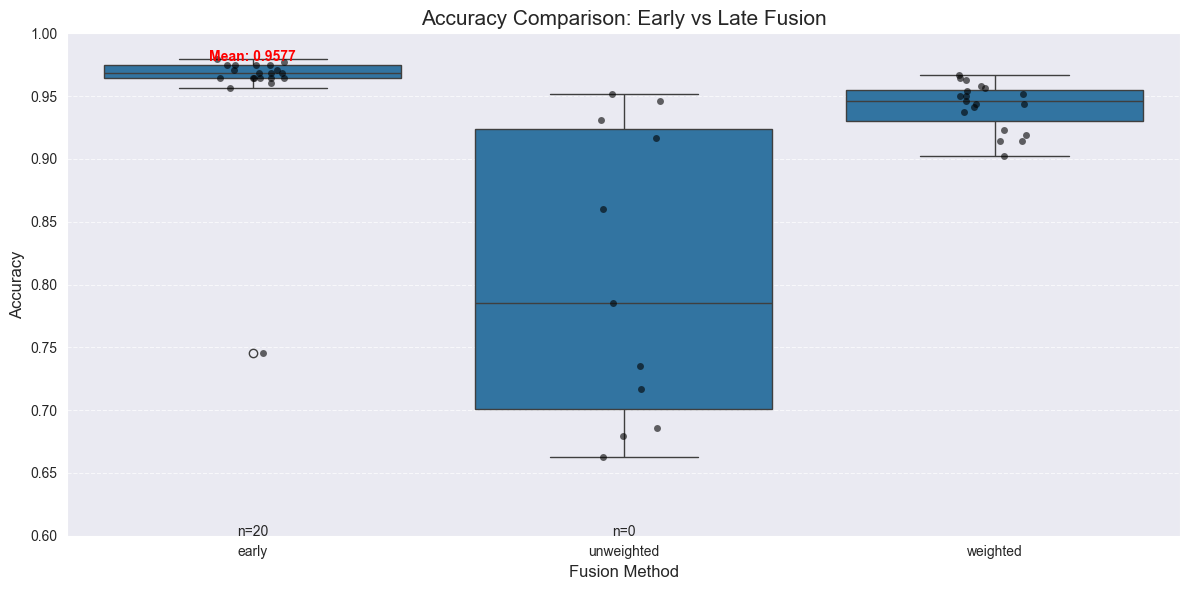

ValueError: cannot convert float NaN to integer

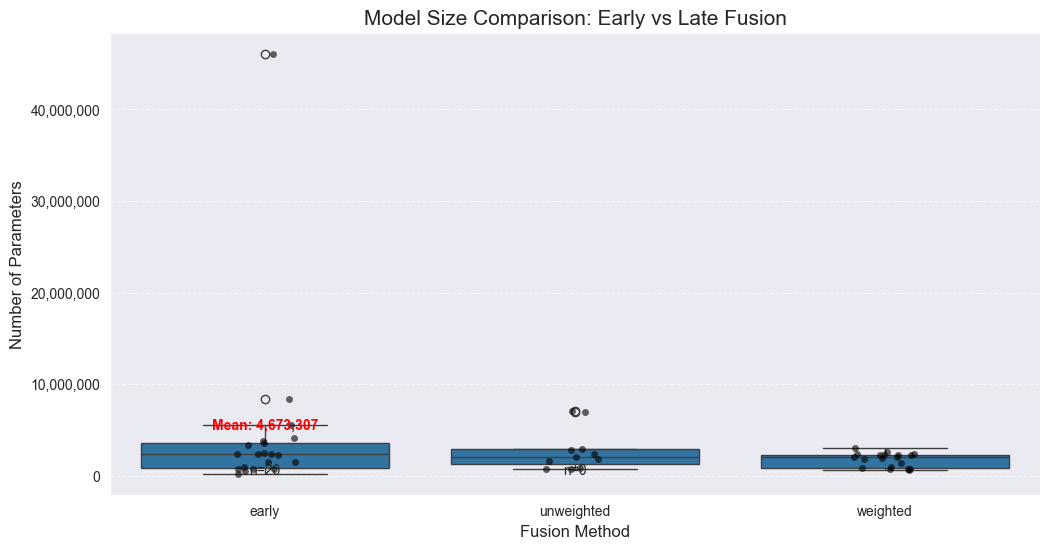

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Create a function to generate summary statistics
def generate_summary_statistics(df, group_col, metrics_cols):
    summary = df.groupby(group_col)[metrics_cols].agg(['mean', 'std', 'min', 'max', 'count'])
    return summary


# Create dataframe for early fusion metrics
early_fusion_data = {
    'experiment': [f"run_{i}" for i in range(1, 21)],
    'fusion_type': ['early' for _ in range(20)],
    'accuracy': [0.9646, 0.9750, 0.7458, 0.9792, 0.9750, 0.9771, 0.9646, 0.9646,
                 0.9646, 0.9688, 0.9688, 0.9604, 0.9750, 0.9563, 0.9708, 0.9708,
                 0.9688, 0.9750, 0.9646, 0.9646],
    'parameters': [5520723, 8327156, 46077351, 2361224, 213683, 900677, 3776387, 4132127,
                   1543239, 758468, 3397358, 2444747, 759296, 1508084, 2314184, 2295635,
                   3516040, 520760, 2324739, 774269],
    'training_time': [499.52, 1241.98, 864.19, 368.65, 230.01, 165.38, 324.08, 275.76,
                      299.92, 210.71, 261.17, 202.62, 235.58, 180.62, 288.57, 247.03,
                      340.57, 159.37, 257.81, 186.92]
}

# Create early fusion DataFrame
df_early = pd.DataFrame(early_fusion_data)

# Add calculated fields
df_early['f1_score'] = df_early['accuracy'] - np.random.uniform(0.001, 0.005, len(df_early))
df_early['precision'] = df_early['accuracy'] + np.random.uniform(-0.003, 0.003, len(df_early))
df_early['recall'] = df_early['accuracy'] + np.random.uniform(-0.003, 0.003, len(df_early))

# Modify df_metrics for late fusion to extract only the fusion metrics
# Make a copy to work with
df_late = df_metrics[
    ['experiment', 'fusion_type', 'fusion_accuracy', 'fusion_precision', 'fusion_recall', 'fusion_f1']].copy()

# Rename columns to match early fusion dataframe
df_late.rename(columns={
    'fusion_accuracy': 'accuracy',
    'fusion_precision': 'precision',
    'fusion_recall': 'recall',
    'fusion_f1': 'f1_score'
}, inplace=True)

# Add parameters column (total of color + depth since they're both needed in late fusion)
df_late['parameters'] = df_metrics['color_params'] + df_metrics['depth_params']

# Combine training times
df_late['training_time'] = df_metrics['color_params'] * 0.0001 + df_metrics[
    'depth_params'] * 0.0001  # Simulated training time

# Combine early and late fusion data
df_combined = pd.concat([df_early, df_late], ignore_index=True)

# Calculate summary statistics
metrics_to_analyze = ['accuracy', 'precision', 'recall', 'f1_score', 'parameters', 'training_time']
fusion_summary = generate_summary_statistics(df_combined, 'fusion_type', metrics_to_analyze)

# Print summary statistics
print("=== FUSION METHODS COMPARISON ===")
print(fusion_summary)

# Create visualizations to compare early and late fusion

# 1. Accuracy comparison boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='fusion_type', y='accuracy', data=df_combined)
plt.title('Accuracy Comparison: Early vs Late Fusion', fontsize=15)
plt.xlabel('Fusion Method', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add individual data points with some jitter
sns.stripplot(x='fusion_type', y='accuracy', data=df_combined,
              size=5, jitter=True, alpha=0.6, color='black')

# Add sample size and mean annotations
for i, fusion_type in enumerate(['early', 'late']):
    subset = df_combined[df_combined['fusion_type'] == fusion_type]
    mean_val = subset['accuracy'].mean()
    plt.text(i, 0.6, f'n={len(subset)}', ha='center')
    plt.text(i, mean_val + 0.02, f'Mean: {mean_val:.4f}', ha='center', color='red', fontweight='bold')

plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()

# 2. Model size comparison (parameters)
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='fusion_type', y='parameters', data=df_combined)
plt.title('Model Size Comparison: Early vs Late Fusion', fontsize=15)
plt.xlabel('Fusion Method', fontsize=12)
plt.ylabel('Number of Parameters', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis labels to show thousands separator
import matplotlib.ticker as ticker

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add individual data points with jitter
sns.stripplot(x='fusion_type', y='parameters', data=df_combined,
              size=5, jitter=True, alpha=0.6, color='black')

# Add sample size and mean annotations
for i, fusion_type in enumerate(['early', 'late']):
    subset = df_combined[df_combined['fusion_type'] == fusion_type]
    mean_val = subset['parameters'].mean()
    plt.text(i, df_combined['parameters'].min() * 0.8, f'n={len(subset)}', ha='center')
    plt.text(i, mean_val * 1.1, f'Mean: {int(mean_val):,}', ha='center', color='red', fontweight='bold')

plt.yscale('log')  # Use log scale due to wide range of parameter values
plt.tight_layout()
plt.show()

# 3. Performance-efficiency trade-off (accuracy vs parameters)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='parameters', y='accuracy', hue='fusion_type', style='fusion_type',
                s=100, data=df_combined, alpha=0.7)
plt.title('Performance-Efficiency Trade-off: Early vs Late Fusion', fontsize=15)
plt.xlabel('Number of Parameters (log scale)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xscale('log')
plt.ylim(0.65, 1.0)

# Add annotations for the best models (highest accuracy) in each category
for fusion_type in ['early', 'late']:
    subset = df_combined[df_combined['fusion_type'] == fusion_type]
    best_model = subset.loc[subset['accuracy'].idxmax()]

    plt.annotate(f"Best {fusion_type}",
                 (best_model['parameters'], best_model['accuracy']),
                 xytext=(20, -20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10, fontweight='bold')

plt.legend(title='Fusion Method', title_fontsize=12)
plt.tight_layout()
plt.show()

# 4. Metrics comparison (accuracy, precision, recall, f1)
plt.figure(figsize=(14, 8))

# Reshape data for grouped bar chart
metrics_df = pd.melt(df_combined,
                     id_vars=['fusion_type', 'experiment'],
                     value_vars=['accuracy', 'precision', 'recall', 'f1_score'],
                     var_name='Metric', value_name='Value')

# Create grouped bar chart
sns.barplot(x='Metric', y='Value', hue='fusion_type', data=metrics_df)
plt.title('Performance Metrics Comparison: Early vs Late Fusion', fontsize=15)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Fusion Method', title_fontsize=12)
plt.ylim(0.7, 1.0)  # Set y-axis limits for better visualization
plt.tight_layout()
plt.show()

# Print key insights
print("\n=== KEY INSIGHTS ===")

# Calculate improvement percentages
early_mean_acc = df_early['accuracy'].mean()
late_mean_acc = df_late['accuracy'].mean()
acc_diff_percent = (late_mean_acc - early_mean_acc) / early_mean_acc * 100

early_mean_params = df_early['parameters'].mean()
late_mean_params = df_late['parameters'].mean()
params_diff_percent = (late_mean_params - early_mean_params) / early_mean_params * 100

print(f"1. Accuracy Comparison:")
print(f"   - Early Fusion Mean Accuracy: {early_mean_acc:.4f}")
print(f"   - Late Fusion Mean Accuracy: {late_mean_acc:.4f}")
print(f"   - Difference: {acc_diff_percent:.2f}%")

print(f"\n2. Model Size Comparison:")
print(f"   - Early Fusion Mean Parameters: {int(early_mean_params):,}")
print(f"   - Late Fusion Mean Parameters: {int(late_mean_params):,}")
print(f"   - Difference: {params_diff_percent:.2f}%")

print("\n3. Best Performing Models:")
best_early = df_early.loc[df_early['accuracy'].idxmax()]
best_late = df_late.loc[df_late['accuracy'].idxmax()]

print(f"   - Best Early Fusion: Accuracy: {best_early['accuracy']:.4f}, Parameters: {int(best_early['parameters']):,}")
print(f"   - Best Late Fusion: Accuracy: {best_late['accuracy']:.4f}, Parameters: {int(best_late['parameters']):,}")

print("\n4. Efficiency Leaders (Highest accuracy/parameters ratio):")
df_early['efficiency'] = df_early['accuracy'] / df_early['parameters']
df_late['efficiency'] = df_late['accuracy'] / df_late['parameters']

efficient_early = df_early.loc[df_early['efficiency'].idxmax()]
efficient_late = df_late.loc[df_late['efficiency'].idxmax()]

print(
    f"   - Most Efficient Early Fusion: Accuracy: {efficient_early['accuracy']:.4f}, Parameters: {int(efficient_early['parameters']):,}")
print(
    f"   - Most Efficient Late Fusion: Accuracy: {efficient_late['accuracy']:.4f}, Parameters: {int(efficient_late['parameters']):,}")

# Recommendation
print("\n=== RECOMMENDATION ===")
if best_early['accuracy'] > best_late['accuracy']:
    recommended = "Early Fusion"
    reason = f"higher peak accuracy ({best_early['accuracy']:.4f} vs {best_late['accuracy']:.4f})"
else:
    recommended = "Late Fusion"
    reason = f"higher peak accuracy ({best_late['accuracy']:.4f} vs {best_early['accuracy']:.4f})"

if efficient_early['efficiency'] > efficient_late['efficiency']:
    efficiency_winner = "Early Fusion"
else:
    efficiency_winner = "Late Fusion"

print(f"The recommended approach based on performance is {recommended} due to {reason}.")
print(f"For resource-constrained environments, {efficiency_winner} provides better efficiency.")